In [27]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [28]:
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [30]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/swimtransformer/Final_Data_CLAHE"

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [32]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [33]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [34]:
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=len(class_names)   # ✅ IMPORTANT
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [35]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 4])


In [36]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [37]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [38]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_swin.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_swin.pth"))
    return model

In [39]:
model = train_model(model, train_loader, val_loader, epochs=10)

Epoch 1/10
Train Loss: 0.8739 | Train Acc: 0.6763
Val Loss: 0.7048 | Val Acc: 0.7364 | Val F1: 0.7271
Best F1: 0.7271
--------------------------------------------------
Epoch 2/10
Train Loss: 0.6354 | Train Acc: 0.7525
Val Loss: 0.6005 | Val Acc: 0.7692 | Val F1: 0.7618
Best F1: 0.7618
--------------------------------------------------
Epoch 3/10
Train Loss: 0.5805 | Train Acc: 0.7713
Val Loss: 0.5540 | Val Acc: 0.7853 | Val F1: 0.7826
Best F1: 0.7826
--------------------------------------------------
Epoch 4/10
Train Loss: 0.5541 | Train Acc: 0.7789
Val Loss: 0.5309 | Val Acc: 0.7915 | Val F1: 0.7888
Best F1: 0.7888
--------------------------------------------------
Epoch 5/10
Train Loss: 0.5378 | Train Acc: 0.7859
Val Loss: 0.5136 | Val Acc: 0.7983 | Val F1: 0.7941
Best F1: 0.7941
--------------------------------------------------
Epoch 6/10
Train Loss: 0.5214 | Train Acc: 0.7924
Val Loss: 0.5036 | Val Acc: 0.7970 | Val F1: 0.7947
Best F1: 0.7947
-------------------------------------

In [40]:
for param in model.parameters():
    param.requires_grad = True

In [41]:
model = train_model(model, train_loader, val_loader, epochs=20)

Epoch 1/20
Train Loss: 0.7369 | Train Acc: 0.7051
Val Loss: 0.4550 | Val Acc: 0.7469 | Val F1: 0.7131
Best F1: 0.7131
--------------------------------------------------
Epoch 2/20
Train Loss: 0.4380 | Train Acc: 0.8121
Val Loss: 0.4381 | Val Acc: 0.8193 | Val F1: 0.8157
Best F1: 0.8157
--------------------------------------------------
Epoch 3/20
Train Loss: 0.4013 | Train Acc: 0.8313
Val Loss: 0.3107 | Val Acc: 0.8713 | Val F1: 0.8708
Best F1: 0.8708
--------------------------------------------------
Epoch 4/20
Train Loss: 0.3700 | Train Acc: 0.8470
Val Loss: 0.3189 | Val Acc: 0.8719 | Val F1: 0.8710
Best F1: 0.8710
--------------------------------------------------
Epoch 5/20
Train Loss: 0.3613 | Train Acc: 0.8442
Val Loss: 0.3394 | Val Acc: 0.8571 | Val F1: 0.8596
Best F1: 0.8710
--------------------------------------------------
Epoch 6/20
Train Loss: 0.3417 | Train Acc: 0.8597
Val Loss: 0.2960 | Val Acc: 0.8731 | Val F1: 0.8718
Best F1: 0.8718
-------------------------------------

In [42]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      0.99       405
             Normal       0.98      0.97      0.97       405
Pneumonia-Bacterial       0.85      0.84      0.84       405
    Pneumonia-Viral       0.83      0.84      0.83       405

           accuracy                           0.91      1620
          macro avg       0.91      0.91      0.91      1620
       weighted avg       0.91      0.91      0.91      1620



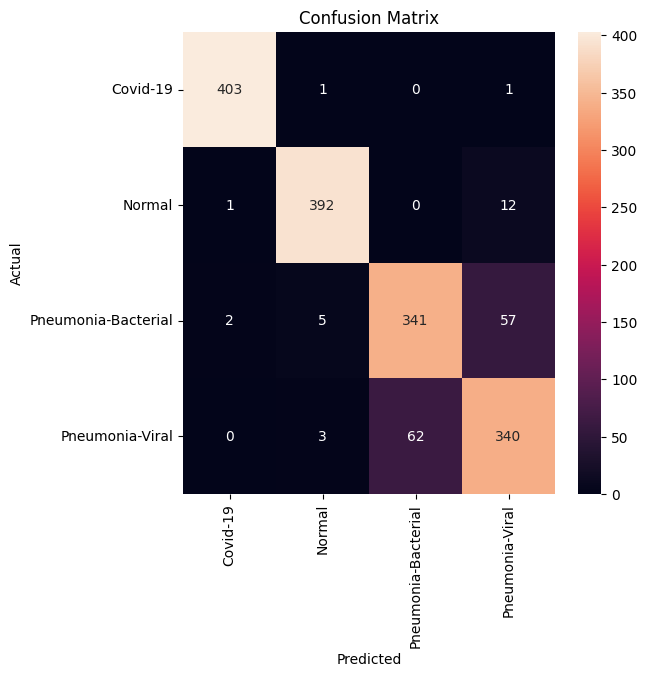

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

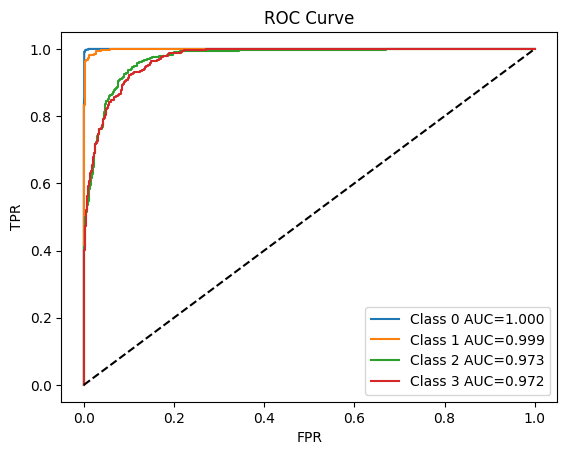

In [44]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

num_classes = all_probs.shape[1]
all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()

        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1,2))

        cam = torch.zeros(activations.shape[1:], device=x.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max()

        return cam.detach().cpu().numpy()

In [46]:
import torch
import numpy as np

def swin_explain(model, img):
    model.eval()

    with torch.no_grad():
        features = model.forward_features(img)

    # 🔥 CASE 1: If output is (B, C, H, W)
    if len(features.shape) == 4:
        heatmap = features.mean(dim=1).squeeze()  # (H, W)

    # 🔥 CASE 2: If output is (B, N, C)
    elif len(features.shape) == 3:
        tokens = features[:, 1:, :] if features.shape[1] > 1 else features
        tokens = tokens.mean(dim=2)

        size = int(np.sqrt(tokens.shape[1]))
        heatmap = tokens[:, :size*size].reshape(size, size).squeeze()

    else:
        raise ValueError("Unsupported feature shape")

    heatmap = heatmap.cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

In [47]:
images, labels = next(iter(test_loader))

img = images[0:1].to(device)

heatmap = swin_explain(model, img)

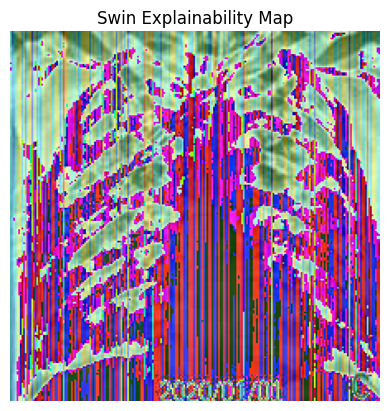

In [48]:
import cv2
import matplotlib.pyplot as plt

img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

overlay = heatmap_color * 0.4 + img_np * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("Swin Explainability Map")
plt.axis('off')
plt.show()

In [49]:
import cv2

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=500, s=8, p1=0.5):
        masks = []

        for _ in range(N):
            mask = (np.random.rand(s, s) < p1).astype(np.float32)
            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)

        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            mask_tensor = torch.tensor(mask).to(self.device)
            masked = image * mask_tensor
            masked = masked.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked), dim=1)

            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i].max() * masks[i]

        saliency /= len(masks)

        return saliency

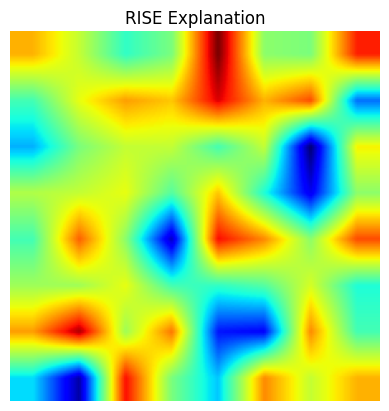

In [50]:
rise = RISE(model, (224,224), device)

images, labels = next(iter(test_loader))
img = images[0].to(device)

masks = rise.generate_masks(N=500)
saliency = rise.explain(img, masks)

plt.imshow(saliency, cmap='jet')
plt.title("RISE Explanation")
plt.axis('off')
plt.show()

In [51]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score,
    cohen_kappa_score
)
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.preprocessing import label_binarize
from scipy import stats

# ===============================
# INPUT (replace with your data)
# ===============================
y_true = np.array(all_labels)   # Ground truth
y_pred = np.array(all_preds)    # Predicted labels

# For AUC (required)
# For multi-class: probabilities required
# Example: y_probs = model outputs after softmax
y_probs = np.array(all_probs)   # shape: (n_samples, n_classes)

# ===============================
# BASIC METRICS
# ===============================
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)

# ===============================
# SPECIFICITY (per class + avg)
# ===============================
specificity_list = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = sum(cm[i, :]) - TP
    FP = sum(cm[:, i]) - TP
    TN = sum(cm) - (TP + FN + FP)

    specificity = TN / (TN + FP + 1e-10)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

# ===============================
# BALANCED ACCURACY
# ===============================
balanced_acc = balanced_accuracy_score(y_true, y_pred)

# ===============================
# AUC-ROC
# ===============================
n_classes = len(np.unique(y_true))

if n_classes == 2:
    auc = roc_auc_score(y_true, y_probs[:, 1])
else:
    y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')

# ===============================
# COHEN'S KAPPA
# ===============================
kappa = cohen_kappa_score(y_true, y_pred)

# ===============================
# 95% CONFIDENCE INTERVAL (Accuracy)
# ===============================
n = len(y_true)
mean_acc = accuracy
std_err = np.sqrt((mean_acc * (1 - mean_acc)) / n)

ci_low, ci_high = stats.norm.interval(0.95, loc=mean_acc, scale=std_err)

# ===============================
# MCNEMAR TEST (compare 2 models)
# ===============================
# You NEED predictions from another model
# Example:
# y_pred_model2 = ...

# contingency table
# [ [n00, n01],
#   [n10, n11] ]

# n01 = model1 correct, model2 wrong
# n10 = model1 wrong, model2 correct

def compute_mcnemar(y_true, y_pred1, y_pred2):
    n01 = np.sum((y_pred1 == y_true) & (y_pred2 != y_true))
    n10 = np.sum((y_pred1 != y_true) & (y_pred2 == y_true))

    table = [[0, n01],
             [n10, 0]]

    result = mcnemar(table, exact=True)
    return result.pvalue

# Example:
# p_value = compute_mcnemar(y_true, y_pred, y_pred_model2)

# ===============================
# PRINT RESULTS
# ===============================
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"Cohen Kappa: {kappa:.4f}")
print(f"95% CI (Accuracy): [{ci_low:.4f}, {ci_high:.4f}]")
# print(f"McNemar p-value: {p_value:.4f}")

Accuracy: 0.9111
Precision (Macro): 0.9114
Recall (Macro): 0.9111
Macro F1: 0.9112
Specificity: -3.0500
Balanced Accuracy: 0.9111
AUC-ROC: 0.9860
Cohen Kappa: 0.8815
95% CI (Accuracy): [0.8973, 0.9250]
